## Importación de librerias y acceso a los datos

In [1]:

# Importamos las librerias necesarias

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    average_precision_score,
    matthews_corrcoef
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM, Bidirectional #, GlobalAveragePooling1D, Dropout, Input, Conv1D, MaxPool1D
from tensorflow.keras.preprocessing.text import Tokenizer #, one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
#from tensorflow.keras.models import Model

import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
2025-05-24 23:45:26.245391: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Leer el archivo tsv y cargar los datos en un DataFrame
# El parámetro sep='\t' indica que el archivo es de tipo TSV (valores separados por tabulaciones)


df1 = pd.read_csv('fake_news/test.tsv', sep='\t')
df2 = pd.read_csv('fake_news/train.tsv', sep='\t')
df3 = pd.read_csv('fake_news/validation.tsv', sep='\t')

In [3]:
# Combina los tres DataFrames (df1, df2, df3) en uno solo llamado 'data'
# El parámetro ignore_index=True reinicia el índice en el DataFrame resultante

data = pd.concat([df1, df2, df3], ignore_index=True)

# Crea una copia de seguridad del DataFrame combinado llamado 'data_backup'

data_backup = pd.concat([df1, df2, df3], ignore_index=True)

# Muestra las columnas del DataFrame 'data' y su forma (número de filas y columnas)
data.columns, data.shape

(Index(['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label'], dtype='object'),
 (44267, 6))

In [4]:
# Proporciona un resumen conciso del DataFrame 'data'
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44267 entries, 0 to 44266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  44267 non-null  int64 
 1   title       44267 non-null  object
 2   text        44267 non-null  object
 3   subject     44267 non-null  object
 4   date        44267 non-null  object
 5   label       44267 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 2.0+ MB


In [5]:
# Muestra las primeras 5 filas del DataFrame 'data'

data.head()

,Unnamed: 0,title,text,subject,date,label
0,8104,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,7467,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,9473,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,276,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,19274,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0


In [6]:
# Cuenta el número de valores nulos en cada columna del DataFrame 'data'

data.isnull().sum()

Unnamed: 0    0
title         0
text          0
subject       0
date          0
label         0
dtype: int64

## Selección y tratamiento de las columnas relevantes

In [7]:
# Eliminamos columnas inecesarias

data = data.drop(["Unnamed: 0","date"], axis = 1)

# Muestra las primeras 5 filas del DataFrame 'data' después de eliminar las columnas

data.head()

,title,text,subject,label
0,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,0
1,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,1
2,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,0
3,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,1
4,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,0


In [8]:
# Crea una nueva columna llamada 'total_n' en el DataFrame 'data'
# Esta nueva columna es el resultado de concatenar el contenido de las columnas 'title' y 'text'
# Se añade un espacio entre el título y el texto para separarlos adecuadamente

data['total_n'] = data['title'] + ' ' + data['text']
data.head()

,title,text,subject,label,total_n
0,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,0,Conservatives Will HATE What Donald Trump Just...
1,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,1,Trump victory may create new tension between U...
2,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,0,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...
3,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,1,"Democratic Senator Franken to resign: CNN, cit..."
4,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,0,GANG OF DOMESTIC TERRORISTS Violently Attack L...


In [9]:
# Genera e imprime estadísticas descriptivas de la columna 'total_n' en el DataFrame 'data'
# Esto incluye:
# - count: Número total de entradas no nulas
# - unique: Número de valores únicos
# - top: La entrada más frecuente (moda)
# - freq: La frecuencia de la entrada más frecuente
print(data['total_n'].describe())

count                                                 44267
unique                                                38655
top       Highlights: The Trump presidency on April 13 a...
freq                                                      8
Name: total_n, dtype: object


In [10]:
# mostramos un dato aleatorio de la columna 'total_n' del DataFrame 'data'
data['total_n'][0]

'Conservatives Will HATE What Donald Trump Just Said About Planned Parenthood (VIDEO) Donald Trump isn t exactly a stranger to making large groups of people angry   women, African-Americans, Hispanics, Muslims, and mainstream Republicans all despise The Donald. One group, however, has always strongly supported him   the Stupid Part of America   and he s about to lose them, too. Trump s popularity with conservatives has soared since he began screaming about a god he will never actually understand, baby parts, and other favorite talking points of theirs   but his recent remarks about Planned Parenthood may lose him a lot of support among the segment of the population who are dumb enough to fall for heavily-edited propaganda videos.At the insanely heated GOP debate, Ted Cruz managed to trick The Donald into defending Planned Parenthood. During one of the screaming matches between Trump and Cruz that have become rather commonplace, the Texas Senator accused the billionaire of supporting fe

In [11]:
# Baraja aleatoriamente las filas del DataFrame 'data'
# El parámetro frac=1 indica que se barajan todas las filas

data = data.sample(frac=1)

# Restablece el índice del DataFrame 'data' después del barajado
# inplace=True significa que la operación se realiza directamente en el DataFrame sin necesidad de asignarlo de nuevo

data.reset_index(inplace=True)

# Elimina la columna 'index' que se creó al restablecer el índice

data.drop(["index"], axis=1, inplace=True)

## Cargamos el diccionario relavante

In [12]:

# Obtiene la lista de palabras vacías en inglés del módulo stopwords de NLTK

stop_words = stopwords.words('english')

# Extiende la lista de palabras vacías con palabras adicionales específicas
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

In [13]:

def preprocess(text):
    # Inicializa una lista vacía para almacenar los tokens procesados

    result = []
    # Itera sobre cada token en el texto preprocesado utilizando gensim.utils.simple_preprocess
    # simple_preprocess realiza tokenización básica y normalización (por ejemplo, convertir a minúsculas)
    for token in gensim.utils.simple_preprocess(text):

        # Filtra los tokens según las siguientes condiciones:
        # 1. El token no debe estar en la lista de palabras vacías de Gensim
        # 2. La longitud del token debe ser mayor que 3 caracteres
        # 3. El token no debe estar en la lista de palabras vacías personalizada (stop_words)

        if token not in gensim.parsing.preprocessing.STOPWORDS and len(token) > 3 and token not in stop_words:
            # Si el token pasa todos los filtros, se añade a la lista de resultados

            result.append(token)
    
    # Devuelve la lista de tokens procesados
    return result

In [14]:
# Activa la integración de tqdm con pandas
# Esto permite usar progress_apply en lugar de apply para mostrar una barra de progreso
tqdm.pandas()

# Aplica la función preprocess a cada elemento de la columna 'total_n' en el DataFrame 'data'
# progress_apply es similar a apply, pero muestra una barra de progreso gracias a tqdm
data['clean'] = data['total_n'].progress_apply(preprocess)

100%|██████████| 44267/44267 [00:40<00:00, 1098.47it/s]


In [15]:
# Inicializa una lista vacía para almacenar todas las palabras
list_of_words = []

# Itera sobre cada elemento en la columna 'clean' del DataFrame 'data'
# Cada elemento en 'clean' es una lista de palabras (preprocesadas)
for i in data.clean:
        
    # Itera sobre cada palabra en la lista de palabras
    for j in i:
        # Añade cada palabra a la lista única 'list_of_words'
        list_of_words.append(j)
# Calcula y devuelve la longitud de 'list_of_words', es decir, el número total de palabras
len(list_of_words)


9222321

In [16]:
# Convierte la lista de palabras 'list_of_words' en un conjunto (set) para eliminar duplicados
total_words = len(list(set(list_of_words)))
total_words

108577

In [17]:
# Aplica una función lambda a cada elemento de la columna 'clean' en el DataFrame 'data'
# La función lambda une las palabras en cada lista en una sola cadena de texto, separadas por espacios
# Los resultados se almacenan en una nueva columna llamada 'clean_joined'
data['clean_joined'] = data['clean'].apply(lambda x: " ".join(x))

# Comparamos el texto original y el texto preprocesado y unido
data[['total_n', 'clean_joined']].head()


,total_n,clean_joined
0,Trump administration weighs tighter vetting fo...,trump administration weighs tighter vetting wo...
1,Turkey's border with northern Iraq remains ope...,turkey border northern iraq remains open minis...
2,Britain seeks to smooth Brexit path for nuclea...,britain seeks smooth brexit path nuclear power...
3,JACK-ASS-IN-CHIEF: OBAMA USES SPEECH ON WORLD ...,jack chief obama uses speech world stage apolo...
4,"Flynn's lawyers cut talks with Trump team, sig...",flynn lawyers talks trump team signaling muell...


In [18]:
data.head()

,title,text,subject,label,total_n,clean,clean_joined
0,Trump administration weighs tighter vetting fo...,The Trump administration is considering tighte...,politicsNews,1,Trump administration weighs tighter vetting fo...,"[trump, administration, weighs, tighter, vetti...",trump administration weighs tighter vetting wo...
1,Turkey's border with northern Iraq remains ope...,Turkey s border with northern Iraq remains ope...,worldnews,1,Turkey's border with northern Iraq remains ope...,"[turkey, border, northern, iraq, remains, open...",turkey border northern iraq remains open minis...
2,Britain seeks to smooth Brexit path for nuclea...,The British government said on Thursday it was...,worldnews,1,Britain seeks to smooth Brexit path for nuclea...,"[britain, seeks, smooth, brexit, path, nuclear...",britain seeks smooth brexit path nuclear power...
3,JACK-ASS-IN-CHIEF: OBAMA USES SPEECH ON WORLD ...,"For the umpteenth time, Obama takes the opport...",politics,0,JACK-ASS-IN-CHIEF: OBAMA USES SPEECH ON WORLD ...,"[jack, chief, obama, uses, speech, world, stag...",jack chief obama uses speech world stage apolo...
4,"Flynn's lawyers cut talks with Trump team, sig...","Lawyers for Michael Flynn, President Donald Tr...",politicsNews,1,"Flynn's lawyers cut talks with Trump team, sig...","[flynn, lawyers, talks, trump, team, signaling...",flynn lawyers talks trump team signaling muell...


## Plots Ilustrativos

<Axes: xlabel='label', ylabel='count'>

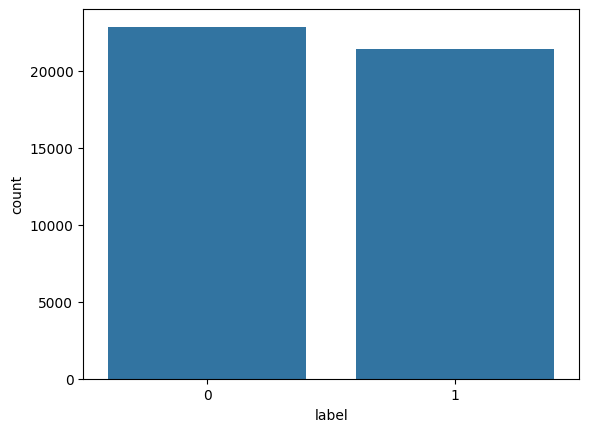

In [19]:
# Creamos un gráfico de conteo utilizando seaborn
# data=data: Especifica el DataFrame que se utilizará para los datos
# x='label': Indica que la variable categórica a contar es la columna 'label'
# order=data['label'].value_counts().index: Ordena las barras según la frecuencia de cada categoría en orden descendente
sns.countplot(data=data,
              x='label',
              order=data['label'].value_counts().index)


<Axes: xlabel='count', ylabel='subject'>

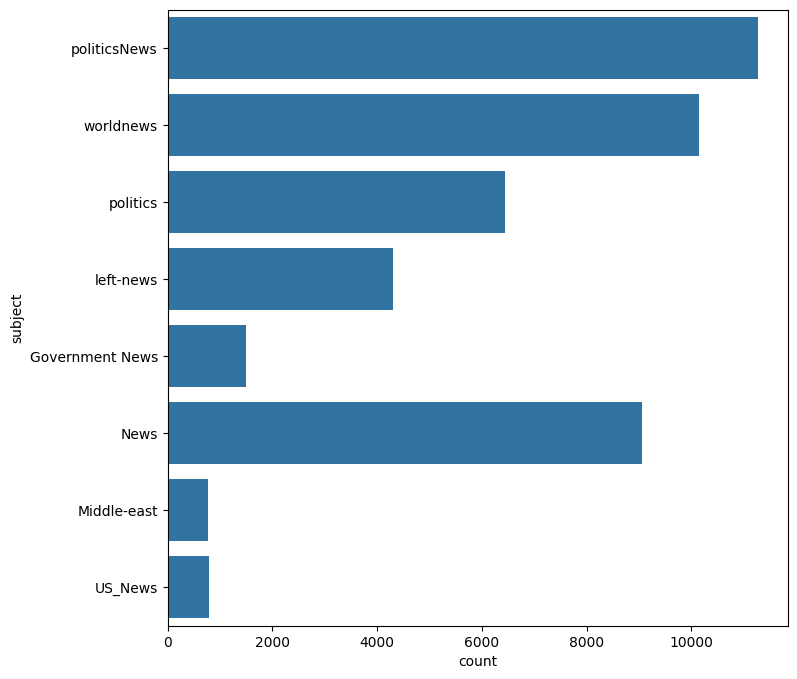

In [20]:
# Crear un gráfico de barras horizontales que cuenta las ocurrencias
# y = "subject": La columna 'subject' se coloca en el eje Y (vertical)
# Al usar y= en lugar de x=, las barras se muestran horizontalmente

plt.figure(figsize = (8, 8))
sns.countplot(y = "subject", data = data)


## WordCloud

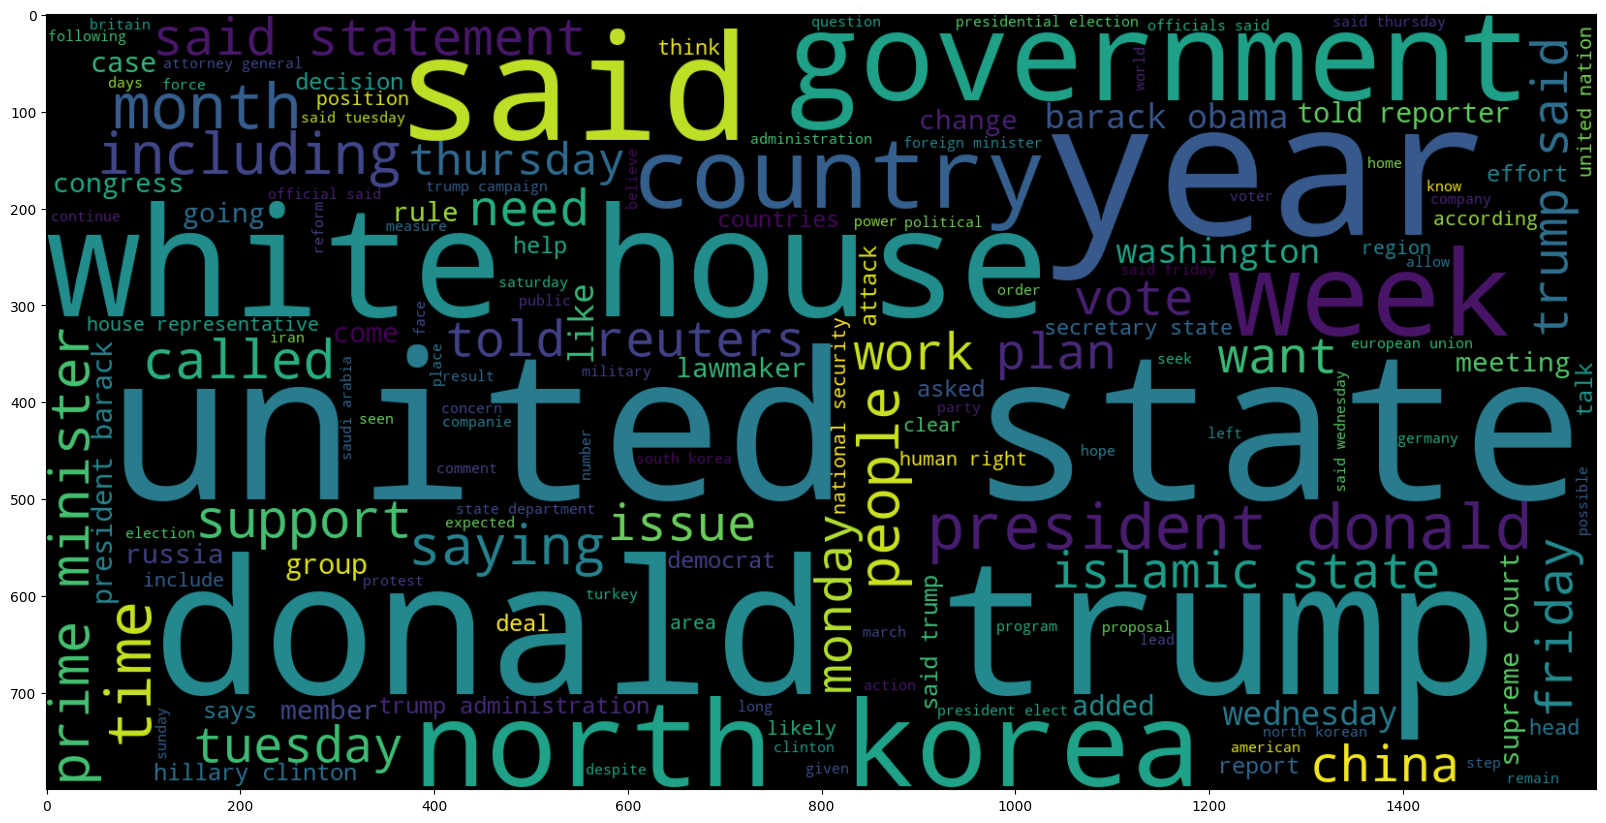

In [21]:
# Crear una figura para mostrar la nube de palabras cuando la etiqueta es 1 (REAL NEWS)
plt.figure(figsize = (20,20)) 
wc = WordCloud(max_words = 150 , width = 1600 , height = 800 , stopwords = stop_words).generate(" ".join(data[data.label == 1].clean_joined))

# Desglosamos esta línea:
# WordCloud(): Crea el objeto generador de nubes de palabras
#   - max_words = 150: Máximo 150 palabras en la nube
#   - width = 1600: Ancho de la imagen generada (1600 píxeles)  
#   - height = 800: Alto de la imagen generada (800 píxeles)
#   - stopwords = stop_words: Palabras a excluir (como "el", "la", "de", etc.)

# .generate(): Genera la nube con el texto proporcionado
# " ".join(): Une todas las palabras con espacios
# data[data.label == 1]: Filtra solo las filas donde label es igual a 1
# .clean_joined: Columna que contiene el texto limpio y procesado

# Mostrar la nube de palabras como imagen
plt.imshow(wc, interpolation = 'bilinear')

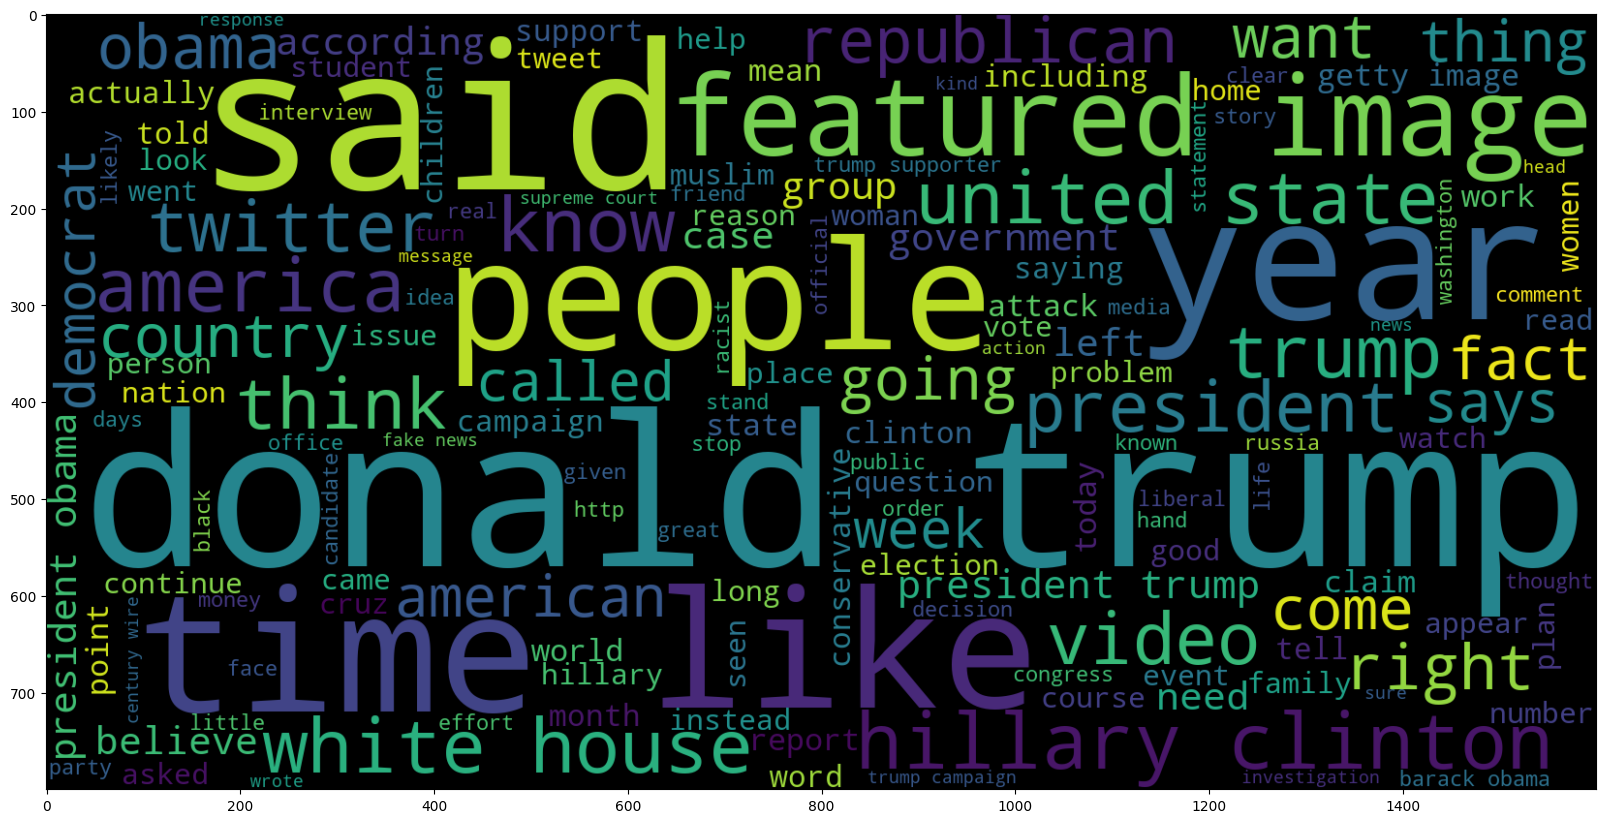

In [22]:
# Crear una figura para mostrar la nube de palabras cuando la etiqueta es 1 (FAKE NEWS)
plt.figure(figsize = (20,20)) 
wc = WordCloud(max_words = 150 , width = 1600 , height = 800 , stopwords = stop_words).generate(" ".join(data[data.label == 0].clean_joined))
plt.imshow(wc, interpolation = 'bilinear')

## Tokenizacion

In [23]:
# Inicializar la variable que guardará la longitud máxima
# Se usa -1 para asegurar que cualquier documento (incluso vacío con 0 tokens)

maxlen = -1

# Iterar por cada documento en la columna de texto limpio
for doc in data.clean_joined:

    # doc: cada fila/documento individual de la columna 'clean_joined'
    
    # Tokenizar el documento (dividir el texto en palabras individuales)

    tokens = nltk.word_tokenize(doc)
    # nltk.word_tokenize(): Separa el texto en tokens (palabras, signos de puntuación)
    # Ejemplo: "Hola mundo!" → ['Hola', 'mundo', '!']
    # tokens: lista con todas las palabras del documento actual

    if(maxlen<len(tokens)):
        
        # len(tokens): cuenta cuántos tokens/palabras tiene el documento actual
        maxlen = len(tokens)
print("The maximum number of words in any document is =", maxlen)
# Imprime el número máximo de palabras encontrado en cualquier documento

The maximum number of words in any document is = 4405


In [24]:
# plotly.express: Librería para crear gráficos interactivos de forma sencilla
import plotly.express as px

# Crear un histograma interactivo

fig = px.histogram(x = [len(nltk.word_tokenize(x)) for x in data.clean_joined], nbins = 100)
fig.show()

## Split Data


In [25]:
# Dividir los datos en conjuntos de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(data.clean_joined, data.label, test_size = 0.2)

In [26]:
# Crear el tokenizador con un vocabulario limitado

tokenizer = Tokenizer(num_words = total_words)
# Tokenizer(): Convierte texto en secuencias numéricas para redes neuronales
# num_words = total_words: Limita el vocabulario a las 'total_words' palabras más frecuentes

tokenizer.fit_on_texts(x_train)
# Entrenar el tokenizador con los datos de entrenamiento. Sololo hacemos en el subset de training para evitar filtrado de informacion al subset de test
# fit_on_texts(): Analiza todos los textos de entrenamiento

train_sequences = tokenizer.texts_to_sequences(x_train)
# Convertir textos de entrenamiento a secuencias numéricas
# texts_to_sequences(): Convierte cada texto en una lista de números


test_sequences = tokenizer.texts_to_sequences(x_test)
# Convertir textos de prueba a secuencias numéricas
# Usa el MISMO diccionario creado con los datos de entrenamiento
# No se entrena de nuevo, solo convierte usando el vocabulario existente
# Si encuentra palabras nuevas (no vistas en entrenamiento), las ignora


## Padding

In [27]:
# Aplicar padding a las secuencias de entrenamiento
# pad_sequences(): Hace que todas las secuencias tengan la misma longitud
# train_sequences: Las listas de números de longitud variable
# maxlen = 40: Todas las secuencias tendrán exactamente 40 números
padded_train = pad_sequences(train_sequences,maxlen = 40, padding = 'post', truncating = 'post')

# Aplicar padding a las secuencias de prueba
padded_test = pad_sequences(test_sequences,maxlen = 40, truncating = 'post') 

# Mostrar ejemplos de las primeras 2 secuencias procesadas
for i,doc in enumerate(padded_train[:2]):
     print("The padded encoding for document",i+1," is : ",doc)

# i+1: Para mostrar "documento 1, documento 2" en lugar de "0, 1"


The padded encoding for document 1  is :  [    1  3334  4370  7544  1239  1978  1328  1444    25    56   377   448
  4370   417     9     1  5651  7422 38167 35081    71    16   701    13
   418  5494  1444   812     1  2805  7422 18224     1  1532  4928  1556
   196    38  2143  4370]
The padded encoding for document 2  is :  [   95  2404  5586    17  1988  3497    30 14079  1045    83  2088  5652
   345 24066    25   409   909    52  2404  3719  8459  4023     1   904
    17  5820  6389 14737   864  1053     1   904  4092   423  1773 13024
    30  5433  2768  1231]


## Red Neural

In [28]:
# Crear un modelo secuencial (capas apiladas)
model = Sequential()

# Capa de embedding - convierte números en vectores densos
model.add(Embedding(total_words, output_dim = 128))
# Embedding(): Transforma índices de palabras en vectores de números reales
# total_words: tamaño del vocabulario (ej: 10,000 palabras únicas)
# output_dim = 128: cada palabra se representa con un vector de 128 números

# Capa LSTM bidireccional - procesa secuencias en ambas direcciones
model.add(Bidirectional(LSTM(128)))
# LSTM(128): Red neuronal recurrente con 128 unidades de memoria
# Bidirectional(): Procesa la secuencia hacia adelante Y hacia atrás

# Capa densa con activación ReLU - procesamiento no lineal

model.add(Dense(128, activation = 'relu'))
# Dense(128): Capa completamente conectada con 128 neuronas
# activation = 'relu': ReLU elimina valores negativos (max(0, x))
# Permite al modelo aprender patrones complejos no lineales

# Capa de salida - clasificación binaria

model.add(Dense(1,activation= 'sigmoid'))
# Dense(1): Una sola neurona de salida
# activation = 'sigmoid': Convierte cualquier número a probabilidad (0-1)

# Compilar el modelo - definir cómo aprenderá
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
# optimizer='adam': Algoritmo de optimización (actualiza los pesos eficientemente)
# loss='binary_crossentropy': Función de pérdida para clasificación binaria

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Entrenar el modelo y guardar el historial de entrenamiento

history = model.fit(padded_train, y_train, epochs=5, batch_size=64, validation_data=(padded_test, y_test))

Epoch 1/5
554/554 ━━━━━━━━━━━━━━━━━━━━ 85s 145ms/step - acc: 0.9159 - loss: 0.1931 - val_acc: 0.9764 - val_loss: 0.0647
Epoch 2/5
554/554 ━━━━━━━━━━━━━━━━━━━━ 84s 151ms/step - acc: 0.9954 - loss: 0.0150 - val_acc: 0.9766 - val_loss: 0.0671
Epoch 3/5
554/554 ━━━━━━━━━━━━━━━━━━━━ 81s 146ms/step - acc: 0.9984 - loss: 0.0043 - val_acc: 0.9783 - val_loss: 0.0818
Epoch 4/5
554/554 ━━━━━━━━━━━━━━━━━━━━ 87s 158ms/step - acc: 0.9987 - loss: 0.0035 - val_acc: 0.9722 - val_loss: 0.1031
Epoch 5/5
554/554 ━━━━━━━━━━━━━━━━━━━━ 88s 158ms/step - acc: 0.9992 - loss: 0.0025 - val_acc: 0.9754 - val_loss: 0.1207


In [30]:
# Convertir las etiquetas de entrenamiento a arrays de NumPy

y_train = np.asarray(y_train)

# Convertir las etiquetas de prueba a arrays de NumPy

y_test = np.asarray(y_test)

## Performance del modelo


In [31]:
# Realizar predicciones con el modelo entrenado

pred = model.predict(padded_test)

277/277 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step


In [32]:
# Inicialización de una lista vacía llamada 'prediction' que almacenará los resultados
prediction = []
# Bucle que itera sobre cada elemento en la lista 'pred' (usando su longitud como rango)
for i in range(len(pred)):
    # - Se compara si este valor es mayor que 0.95 (umbral de confianza)
    # Si es mayor que 0.95, se agrega un 1 a la lista 'prediction' (clase positiva)
    if pred[i].item() > 0.95:
        prediction.append(1)
        
    # Si es menor o igual que 0.95, se agrega un 0 a la lista 'prediction' (clase negativa)
    else:
        prediction.append(0)

In [33]:
# Calcula la precisión (accuracy) del modelo comparando las etiquetas reales (y_test) con las predicciones
accuracy = accuracy_score(list(y_test), prediction)

print("Model Accuracy : ", accuracy)

Model Accuracy :  0.9743618703410888


## Matriz de Confusion

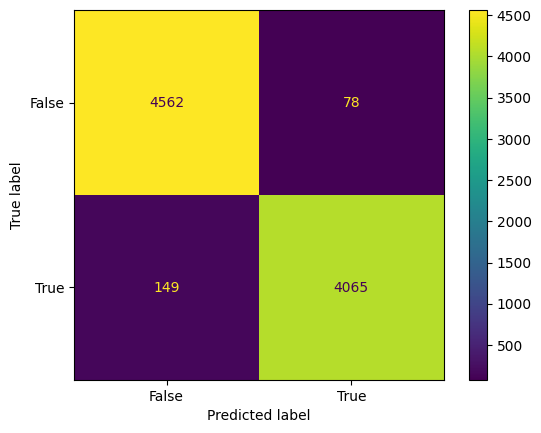

In [34]:
# ConfusionMatrixDisplay: Clase para visualización de matrices de confusión
cm = metrics.confusion_matrix(y_test, prediction)

# display_labels: Define cómo se etiquetarán las clases en el gráfico
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                            display_labels=[False, True])

cm_display.plot()
plt.show()

## Metricas Adicionales

ROC AUC Score: 0.9964


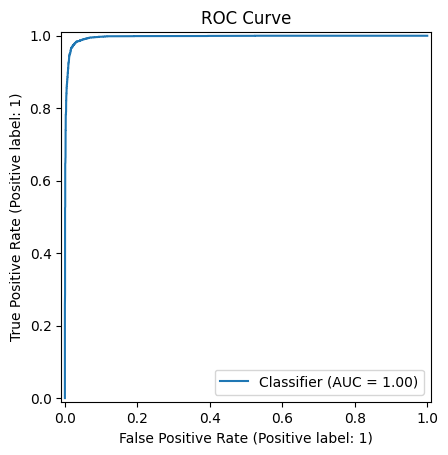

In [35]:
# Calcula el área bajo la curva ROC (ROC AUC Score)
#  La curva ROC es útil para evaluar modelos de clasificación binaria
# Muestra el trade-off entre sensibilidad y especificidad
# Cuanto más cerca esté la curva de la esquina superior izquierda, mejor el modelo

roc_auc = roc_auc_score(y_test, pred)
print(f"ROC AUC Score: {roc_auc:.4f}")
RocCurveDisplay.from_predictions(y_test, pred)
plt.title('ROC Curve')
plt.show()

Average Precision Score (PR AUC): 0.9957


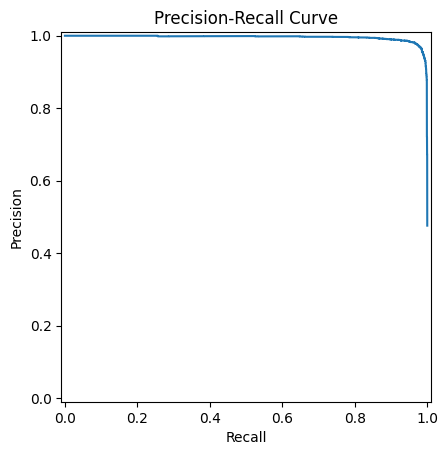

In [36]:
# Calcula la curva Precision-Recall y obtiene los umbrales
# precision_recall_curve(): Función que calcula:
# * precision: Valores de precisión para diferentes umbrales
# * recall: Valores de recall (sensibilidad) para diferentes umbrales
# * thresholds: Umbrales de decisión usados
# y_test: Valores reales/verdaderos
# pred: Probabilidades predichas por el modelo (debe ser scores, no clases 0/1)

precision, recall, thresholds = precision_recall_curve(y_test, pred)

# Calcula el Average Precision Score (PR AUC)
# - average_precision_score(): Calcula el área bajo la curva Precision-Recall
# - Equivale a la precisión promedio ponderada por el recall
# - Valor entre 0 y 1 (1 es perfecto, 0.5 es aleatorio para clases balanceadas)
# - Especialmente útil para problemas con clases desbalanceadas

average_precision = average_precision_score(y_test, pred)
print(f"Average Precision Score (PR AUC): {average_precision:.4f}")
PrecisionRecallDisplay(precision=precision, recall=recall).plot()
plt.title('Precision-Recall Curve')
plt.show()

In [37]:
# Convertir probabilidades a etiquetas de clase binarias (0 o 1) usando umbral de 0.5
y_pred = (pred > 0.5).astype(int)

# Calcular el Coeficiente de Correlación de Matthews (MCC)
mcc = matthews_corrcoef(y_test, y_pred)

print("Matthews Correlation Coefficient:", mcc)

# El MCC varía entre -1 y +1 donde: +1 = Predicción perfecta 0 = Predicción aleatoria (como adivinar) * -1 = Desacuerdo total (predicciones inversas)

Matthews Correlation Coefficient: 0.950742455063692


## Exportamos el modelo

In [38]:
import joblib

# Guardar el modelo entrenado en un archivo llamado 'model.joblib'
joblib.dump(model, 'news_classifier_api/src/models/model.joblib')


['news_classifier_api/src/models/model.joblib']